# IMPORTING PACKAGES

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# FIGS 1-2-3

--------------------------------------------------
Sampling frequency fs       = 1000.000 Hz
Sampling interval dt        = 0.001000 s
Record length T_rec         = 59.999 s
Number of samples N         = 60000
Sample standard deviation   = 1.009204
Estimated tau_int           = 0.046836 s
Truncation lag tau_m        = 0.149000 s
Estimated N_eff             = 640.525
Std. uncertainty if indep   = 4.120059e-03
Std. uncertainty corrected  = 3.987594e-02
--------------------------------------------------


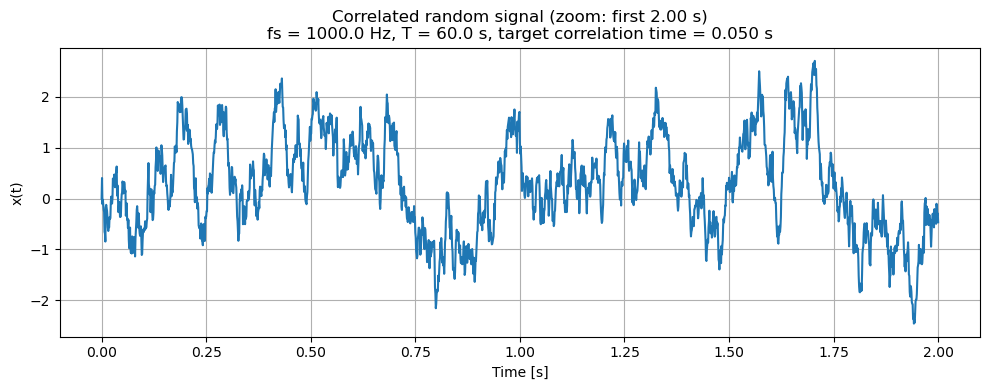

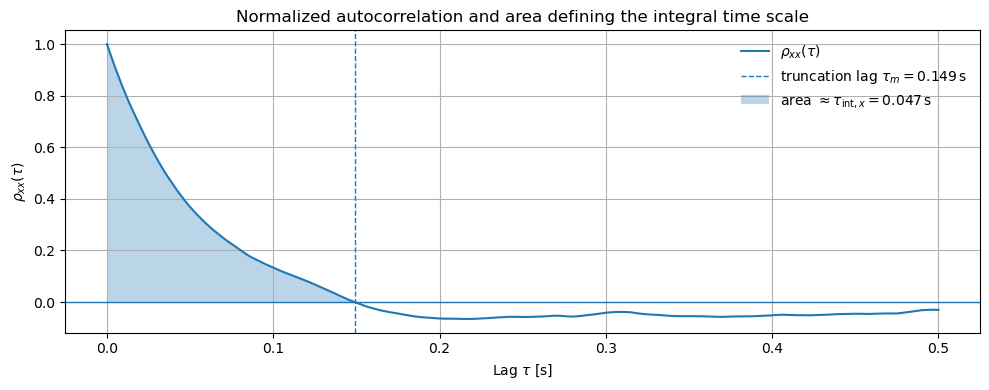

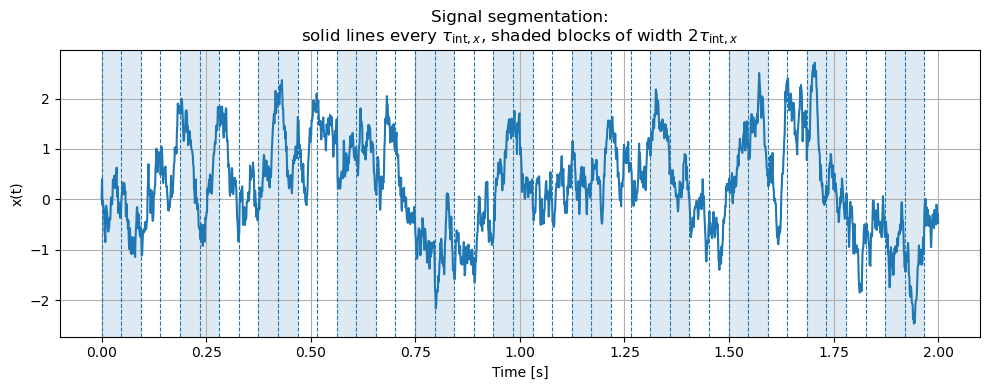

In [3]:
#--------------------------------------------------------------------------------------------------------------------#
#-----------------------------------------generate_correlated_signal() FUNCTION--------------------------------------#
#--------------------------------------------------------------------------------------------------------------------#
def generate_correlated_signal(fs=100.0, T=60.0, tau_c=0.05, sigma=1.0, seed=1):
    """
    Generate a zero-mean correlated Gaussian signal using a discrete-time
    Ornstein-Uhlenbeck / AR(1)-type process.

    The Ornstein-Uhlenbeck / AR(1) process has an autocorrelation function
    that follows:
    
        rho(k * dt) = phi**k

    where ``phi`` is the AR(1) coefficient, ``dt`` is the sampling interval,
    and ``k`` is the lag index.

    To match this discrete autocorrelation with the continuous exponential decay:

        exp(-k * dt / tau_c),

    the AR(1) coefficient is chosen as:

        phi = exp(-dt / tau_c).

    With this choice:

        phi**k = exp(-k * dt / tau_c),

    so the discrete autocorrelation matches the continuous exponential decay
    exactly at the sampled lag times.

    Parameters
    ----------
    fs : float
        Sampling frequency [Hz]
    T : float
        Record duration [s]
    tau_c : float
        Target correlation time [s]
    sigma : float
        Target standard deviation of the signal
    seed : int
        Random seed

    Returns
    -------
    t : ndarray
        Time array
    x : ndarray
        Correlated signal
    dt : float
        Sampling interval
    """

    #--------------------------------------------------------------------------------------------------------------------#
    #---------------------------------------------------------BODY-------------------------------------------------------#
    #--------------------------------------------------------------------------------------------------------------------#
    
    # Random variable realization from seed.
    rng = np.random.default_rng(seed)

    # Computing time-step.
    dt = 1.0 / fs
    # Computing number of samples.
    n = int(T * fs)
    # Computing time-serires array.
    t = np.arange(n) * dt

    # AR(1) coefficient chosen so that rho(k dt) ~ exp(-k dt / tau_c)
    a = np.exp(-dt / tau_c)

    # Drive noise scaled so stationary std is sigma
    noise_std = sigma * np.sqrt(1.0 - a**2)

    # Instantiating x-series as an empty serires.
    x = np.zeros(n)
    # 'for' loop fillng up the x-series.
    for i in range(1, n):
        x[i] = a * x[i - 1] + noise_std * rng.standard_normal()

    #--------------------------------------------------------------------------------------------------------------------#
    #--------------------------------------------------------RETURN------------------------------------------------------#
    #--------------------------------------------------------------------------------------------------------------------#    
    
    # Return statement.
    return t, x, dt

#--------------------------------------------------------------------------------------------------------------------#
#------------------------------------------autocorrelation_unbiased() FUNCTION---------------------------------------#
#--------------------------------------------------------------------------------------------------------------------#
def autocorrelation_unbiased(x, max_lag=None):
    """
    Unbiased autocorrelation estimate normalized so rho[0] = 1.
    """

    #--------------------------------------------------------------------------------------------------------------------#
    #---------------------------------------------------------BODY-------------------------------------------------------#
    #--------------------------------------------------------------------------------------------------------------------#    
    
    # Casting x into an array-type variable.
    x = np.asarray(x, dtype=float)
    # Detrending x.
    x = x - np.mean(x)
    # Getting the length of x.
    n = len(x)

    # Conditional for setting the 'max_lag' variable.
    if max_lag is None:
        max_lag = min(n // 2, n - 1)

    # Instantiating the 'acov' array (autocovariance).
    acov = np.empty(max_lag + 1)
    # 'for' loop filling up the autocovariance array.
    for k in range(max_lag + 1):
        acov[k] = np.dot(x[:n-k], x[k:]) / (n - k)

    # Instantiating the 'rho' variable as the normalized autocovariance array.
    rho = acov / acov[0]

    #--------------------------------------------------------------------------------------------------------------------#
    #--------------------------------------------------------RETURN------------------------------------------------------#
    #--------------------------------------------------------------------------------------------------------------------#    
    
    # Return statement.    
    return rho

#--------------------------------------------------------------------------------------------------------------------#
#-----------------------------------------estimate_tau_int_from_rho() FUNCTION---------------------------------------#
#--------------------------------------------------------------------------------------------------------------------#
def estimate_tau_int_from_rho(rho, dt, truncation="first_nonpositive"):
    """
    Estimate integral time scale from normalized autocorrelation.
    """

    #--------------------------------------------------------------------------------------------------------------------#
    #---------------------------------------------------------BODY-------------------------------------------------------#
    #--------------------------------------------------------------------------------------------------------------------#
    
    if truncation == "first_nonpositive":
        nonpos = np.where(rho[1:] <= 0.0)[0]
        if nonpos.size == 0:
            m = len(rho) - 1
        else:
            m = int(nonpos[0])  # last positive lag before first non-positive
    elif truncation == "all_positive":
        pos = np.where(rho[1:] > 0.0)[0]
        if pos.size == 0:
            m = 0
        else:
            m = int(pos[-1] + 1)
    else:
        raise ValueError("Unsupported truncation option.")

    if m == 0:
        tau_int = 0.5 * dt
    else:
        tau_int = dt * (0.5 + np.sum(rho[1:m+1]))

    #--------------------------------------------------------------------------------------------------------------------#
    #--------------------------------------------------------RETURN------------------------------------------------------#
    #--------------------------------------------------------------------------------------------------------------------#    
    
    # Return statement.    
    return tau_int, m


#--------------------------------------------------------------------------------------------------------------------#
#------------------------------------------------make_figures() FUNCTION---------------------------------------------#
#--------------------------------------------------------------------------------------------------------------------#
def make_figures(fs=1000.0, T=60.0, tau_c=0.05, sigma=1.0, seed=1,
                 zoom_signal=10.0, max_lag_plot=0.5):
    """
    Generate the example and produce three figures:
    1) time signal
    2) autocorrelation + shaded area defining tau_int
    3) signal with chunking by tau_int and 2*tau_int
    """

    #--------------------------------------------------------------------------------------------------------------------#
    #---------------------------------------------------------BODY-------------------------------------------------------#
    #--------------------------------------------------------------------------------------------------------------------#
    
    # Generating correlated signal.
    t, x, dt = generate_correlated_signal(fs=fs, T=T, tau_c=tau_c, sigma=sigma, seed=seed)
    n = len(x)
    T_rec = t[-1] - t[0]

    # Computing autocorrelation and tau_int.
    max_lag = min(int(max_lag_plot / dt), n - 1)
    rho = autocorrelation_unbiased(x, max_lag=max_lag)
    tau = np.arange(len(rho)) * dt

    tau_int, m = estimate_tau_int_from_rho(rho, dt, truncation="first_nonpositive")
    tau_m = tau[m]

    N_eff = T_rec / (2.0 * tau_int)
    N_eff = np.clip(N_eff, 1.0, n)

    s_x = np.std(x, ddof=1)
    sigma_mean_if_indep = s_x / np.sqrt(n)
    sigma_mean_corr = s_x / np.sqrt(N_eff)

    print("--------------------------------------------------")
    print(f"Sampling frequency fs       = {fs:.3f} Hz")
    print(f"Sampling interval dt        = {dt:.6f} s")
    print(f"Record length T_rec         = {T_rec:.3f} s")
    print(f"Number of samples N         = {n:d}")
    print(f"Sample standard deviation   = {s_x:.6f}")
    print(f"Estimated tau_int           = {tau_int:.6f} s")
    print(f"Truncation lag tau_m        = {tau_m:.6f} s")
    print(f"Estimated N_eff             = {N_eff:.3f}")
    print(f"Std. uncertainty if indep   = {sigma_mean_if_indep:.6e}")
    print(f"Std. uncertainty corrected  = {sigma_mean_corr:.6e}")
    print("--------------------------------------------------")

    # Figure 1: signal realization
    fig1 = plt.figure(figsize=(10, 4))
    mask_zoom = t <= zoom_signal
    plt.plot(t[mask_zoom], x[mask_zoom])
    plt.xlabel("Time [s]")
    plt.ylabel("x(t)")
    plt.title(
        f"Correlated random signal (zoom: first {zoom_signal:.2f} s)\n"
        f"fs = {fs:.1f} Hz, T = {T:.1f} s, target correlation time = {tau_c:.3f} s"
    )
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("Figs/01_raw_time_signal.svg")

    # Figure 2: normalized autocorrelation + area for tau_int
    fig2 = plt.figure(figsize=(10, 4))
    plt.plot(tau, rho, label=r"$\rho_{xx}(\tau)$")
    plt.axhline(0.0, linewidth=1.0)
    plt.axvline(tau_m, linestyle="--", linewidth=1.0,
                label=fr"truncation lag $\tau_m={tau_m:.3f}\,$s")
    plt.fill_between(tau[:m+1], rho[:m+1], 0.0, alpha=0.3,
                     label=fr"area $\approx \tau_{{\mathrm{{int}},x}}={tau_int:.3f}\,$s")
    plt.xlabel(r"Lag $\tau$ [s]")
    plt.ylabel(r"$\rho_{xx}(\tau)$")
    plt.title("Normalized autocorrelation and area defining the integral time scale")
    plt.legend(frameon=False)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("Figs/02_normalized_autocorrelation.svg")

    # Figure 3: signal divided into chunks
    fig3 = plt.figure(figsize=(10, 4))
    plt.plot(t[mask_zoom], x[mask_zoom])
    plt.xlabel("Time [s]")
    plt.ylabel("x(t)")
    plt.title(
        "Signal segmentation:\n"
        r"solid lines every $\tau_{\mathrm{int},x}$, shaded blocks of width $2\tau_{\mathrm{int},x}$"
    )
    plt.grid(True)

    # Vertical lines every tau_int (memory time)
    if tau_int > 0:
        n_lines_tau = int(np.floor(zoom_signal / tau_int))
        for j in range(n_lines_tau + 1):
            plt.axvline(j * tau_int, linestyle="--", linewidth=0.8)

    # Shaded blocks of width 2 tau_int (effective independent blocks)
    block = 2.0 * tau_int
    if block > 0:
        n_blocks = int(np.floor(zoom_signal / block))
        for j in range(n_blocks + 1):
            t0 = j * block
            t1 = min((j + 1) * block, zoom_signal)
            if j % 2 == 0:
                plt.axvspan(t0, t1, alpha=0.15)

    plt.tight_layout()
    plt.savefig("Figs/03_chunked_signal.svg")

    return {
        "t": t,
        "x": x,
        "dt": dt,
        "tau": tau,
        "rho": rho,
        "tau_int": tau_int,
        "tau_m": tau_m,
        "N_eff": N_eff,
        "s_x": s_x,
        "sigma_mean_if_indep": sigma_mean_if_indep,
        "sigma_mean_corr": sigma_mean_corr,
    }


results = make_figures(
    fs=1000.0,
    T=60.0,
    tau_c=0.05,
    sigma=1.0,
    seed=3,
    zoom_signal=2.0,
    max_lag_plot=0.5
)

# FIG 4

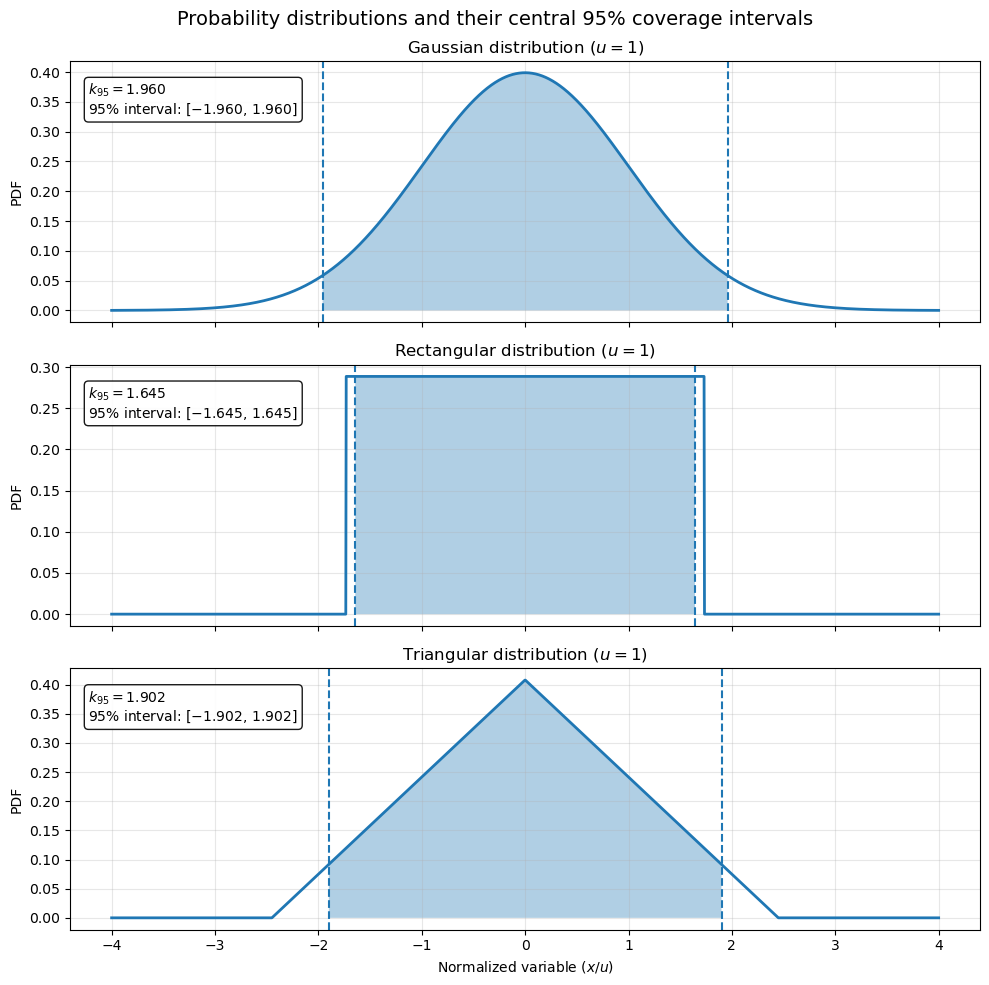

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, pi, erf

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
def normal_pdf(x):
    """Standard normal PDF: mean 0, std 1."""
    return (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * x**2)

def rectangular_pdf(x, a):
    """
    Symmetric rectangular PDF on [-a, a].
    Here a = sqrt(3) so that the standard deviation is 1.
    """
    y = np.zeros_like(x)
    y[np.abs(x) <= a] = 1.0 / (2.0 * a)
    return y

def triangular_pdf(x, a):
    """
    Symmetric triangular PDF on [-a, a].
    Here a = sqrt(6) so that the standard deviation is 1.
    """
    y = np.zeros_like(x)
    mask = np.abs(x) <= a
    y[mask] = (1.0 - np.abs(x[mask]) / a) / a
    return y

# ------------------------------------------------------------
# Parameters
# All distributions are scaled so that std = 1
# ------------------------------------------------------------
a_rect = sqrt(3.0)   # rectangular half-width for std = 1
a_tri  = sqrt(6.0)   # triangular half-width for std = 1

# 95% coverage factors (central intervals)
k95_normal = 1.959963984540054
k95_rect   = 0.95 * sqrt(3.0)
k95_tri    = (1.0 - sqrt(0.05)) * sqrt(6.0)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
x = np.linspace(-4.0, 4.0, 2000)

# PDFs
y_normal = normal_pdf(x)
y_rect   = rectangular_pdf(x, a_rect)
y_tri    = triangular_pdf(x, a_tri)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

plots = [
    (axes[0], y_normal, k95_normal, "Gaussian distribution ($u=1$)"),
    (axes[1], y_rect,   k95_rect,   "Rectangular distribution ($u=1$)"),
    (axes[2], y_tri,    k95_tri,    "Triangular distribution ($u=1$)")
]

for ax, y, k95, title in plots:
    ax.plot(x, y, linewidth=2)
    ax.fill_between(x, 0, y, where=(x >= -k95) & (x <= k95), alpha=0.35)
    ax.axvline(-k95, linestyle="--", linewidth=1.5)
    ax.axvline(+k95, linestyle="--", linewidth=1.5)

    ax.set_title(title)
    ax.set_ylabel("PDF")
    ax.grid(True, alpha=0.3)

    ymax = y.max()
    ax.text(
        0.02, 0.92,
        rf"$k_{{95}} = {k95:.3f}$" "\n"
        rf"95% interval: $[-{k95:.3f},\, {k95:.3f}]$",
        transform=ax.transAxes,
        va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
    )

axes[-1].set_xlabel(r"Normalized variable ($x/u$)")

fig.suptitle(
    "Probability distributions and their central 95% coverage intervals",
    fontsize=14,
    y=0.98
)

plt.tight_layout()
plt.savefig("Figs/04_distributions_coverage_factors.svg")